

# auto ML and TPOT updated
### OPIM 5512 — Applied Data Science · Module2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5512-notebooks/blob/main/Module2/3_autoML and TPOT_updated.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# AutoML and TPOT
**OPIM 5512: Data Science Using Python - University of Connecticut**

---------------------------------
Someone wrote a code to write all of your codes... this is the future...

With AutoML, you can spend more time bringing diverse datasets together and less time 'tuning'/'turning knobs').



# Intro to TPOT

<center>

![tpot logo](https://raw.githubusercontent.com/EpistasisLab/tpot/master/images/tpot-logo.jpg)
**Figure 1:** the TPOT logo

</center>

Consider TPOT your Data Science Assistant! TPOT is a Python Automated Machine Learning tool that **optimizes machine learning pipelines using genetic programming**

### What does TPOT do?

It performs an intelligent search over machine learning pipelines that can contain supervised regression models, preprocessors, feature selection techniques, and any other estimator or transformer that follows the scikit-learn API. The TPOT Classifier and TPOTRegressor will also search over the hyperparameters of all objects in the pipeline.

![what does TPOT do?](https://raw.githubusercontent.com/EpistasisLab/tpot/master/images/tpot-ml-pipeline.png)
**Figure 2:** an example of the TPOT processing pipeline with modeling

### Example of an optimized pipeline from TPOT

This is an example of an 'optimal' pipeline derived from TPOT.

![example pipeline](https://raw.githubusercontent.com/EpistasisLab/tpot/master/images/tpot-pipeline-example.png)
**Figure 3:** an example of the fitted pipeline

### Just how easy is it?

Only a few lines of code... this is the future of machine learning!

![Example of TPOT on MNIST](https://raw.githubusercontent.com/EpistasisLab/tpot/master/images/tpot-demo.gif)
**Figure 4:** a GIF of the TPOT fitting on the MNIST dataset

# FAQ on TPOT/autoML
* [Don't run TPOT for a few minutes -link](https://epistasislab.github.io/tpot/latest/Tutorial/1_Using_TPOT/#automl-algorithms-arent-intended-to-run-for-only-a-few-minutes)
* [Basics on fitting the TPOT classifier](https://epistasislab.github.io/tpot/latest/tpot_api/classifier/)
* [Basics on fitting the TPOT regressor](https://epistasislab.github.io/tpot/latest/tpot_api/regressor/#tpot.tpot_estimator.templates.tpottemplates.TPOTRegressor)

# Import Modules/ Install TPOT

In [ ]:
# relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# if it hasn't been already... this is how you install a new module to colab
!pip install tpot

# 🔴 Read Classification Data
We will use the Breast Cancer dataset for demonstration purposes.

In [ ]:
# let's use gdown to get the data instead of mounting the drive
# https://drive.google.com/file/d/1UwCOmgdOwvpMd58lVlwqUL3w1IRaYJa-/view?usp=sharing
!gdown 1UwCOmgdOwvpMd58lVlwqUL3w1IRaYJa-

Downloading...
From: https://drive.google.com/uc?id=1UwCOmgdOwvpMd58lVlwqUL3w1IRaYJa-
To: /content/breastcancer.csv
100% 125k/125k [00:00<00:00, 20.9MB/s]


In [ ]:
df = pd.read_csv('breastcancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


The target variable will be `diagnosis`. Let's drop that last unnamed column while we are here. And since `id` doesn't have predictive power, let's drop that too.

In [ ]:
df.drop('Unnamed: 32', axis=1, inplace=True)
df.drop('id', axis=1, inplace=True)
df.columns # voila - it's gone!

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
df.info() # check for any missing values - all looks good!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

If you look at the unique values in the `diagnosis`, we see that these are... **M** for malignant and **B** for benign.



In [ ]:
from collections import Counter
Counter(df['diagnosis'])

Counter({'M': 212, 'B': 357})

Our data is imbalanced, and we will ignore this for now - we can use SMOTE later on with an imblearn Pipeline (different than an sklearn pipeline - be careful!) So

So that we don't have to deal with problems in a logistic regression, let's use `LabelEncoder()` from `sklearn`.

In [ ]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
df['diagnosis'] = LE.fit_transform(df['diagnosis'])
Counter(df['diagnosis'])

Counter({1: 212, 0: 357})

As you can see, B is 0 and M is 1. You could use SMOTE now before all of your pipelines (if you wanted to use it for everything). But for now, we simply ignore the class balance.

In [ ]:
# Split-out validation df
X = df.drop('diagnosis', axis=1) #covariates - just drop the target!
y = df['diagnosis'] #target variable
validation_size = 0.20
seed = 123 # so you will split the same way and evaluate the SAME dataset

# split!
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=validation_size,
                                                    random_state=seed)

### TPOT for Classification (Breast Cancer)
Warning: this will take quite a bit of time! Look at the hyperparameters here.
* https://epistasislab.github.io/tpot/latest/tpot_api/classifier/

`cv`, `generations` and `max_time` are good ones to check out.

In [ ]:
from tpot import TPOTClassifier
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score  # (you could also use roc_auc_score, f1_score, etc.)
import joblib

# =========================================================
# 0) Train / test split
# =========================================================
# Assumes df is already defined and contains a 'diagnosis' column (target)

X = df.drop('diagnosis', axis=1)   # covariates
y = df['diagnosis']                # target variable

validation_size = 0.20
seed = 123  # so you will split the same way and evaluate the SAME dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=validation_size,
    random_state=seed,
    stratify=y    # usually good for classification
)

# =========================================================
# 1) Construct and fit TPOT classifier
# =========================================================
start_time = time.time()
tpot = TPOTClassifier(
    generations=1,
    cv=3,
    random_state=seed
)
tpot.fit(X_train, y_train)
end_time = time.time()

print("TPOT classifier finished in %.2f seconds" % (end_time - start_time))

# =========================================================
# 2) Evaluate best pipeline on test set
# =========================================================
y_pred = tpot.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Best pipeline test accuracy: %.3f" % acc)

# =========================================================
# 3) Inspect the best pipeline
# =========================================================
print("\nBest pipeline found by TPOT:\n")
print(tpot.fitted_pipeline_)

print("\nPipeline steps (one by one):")
for name, step in tpot.fitted_pipeline_.steps:
    print(f"\nStep: {name}\n{step}\n")

# =========================================================
# 4) Save best pipeline to disk
# =========================================================
model_path = "tpot_breastcancer_pipeline.joblib"
joblib.dump(tpot.fitted_pipeline_, model_path)
print(f"Saved best pipeline to {model_path}")

/usr/local/lib/python3.12/dist-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
/usr/local/lib/python3.12/dist-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44973 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:44497
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:44973/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37805'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:38529 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:38529
INFO:dis

TPOT classifier finished in 161.66 seconds
Best pipeline test accuracy: 0.842

Best pipeline found by TPOT:

Pipeline(steps=[('robustscaler',
                 RobustScaler(quantile_range=(0.2133755475045,
                                              0.7193142391339))),
                ('passthrough', Passthrough()),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('logisticregression',
                 LogisticRegressio

In [ ]:

# =========================================================
# 5) (Optional) Reload and sanity-check
# =========================================================
best_pipe = joblib.load(model_path)
y_pred_loaded = best_pipe.predict(X_test)
acc_loaded = accuracy_score(y_test, y_pred_loaded)
print("Reloaded pipeline test accuracy: %.3f" % acc_loaded)


Reloaded pipeline test accuracy: 0.842


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred_loaded))
print('----------------- ')
print(classification_report(y_test, y_pred_loaded))


[[55 17]
 [ 1 41]]
----------------- 
              precision    recall  f1-score   support

           0       0.98      0.76      0.86        72
           1       0.71      0.98      0.82        42

    accuracy                           0.84       114
   macro avg       0.84      0.87      0.84       114
weighted avg       0.88      0.84      0.84       114



## Run the Model
Note: your pipeline may be a little different due to randomness... but you will still get a GREAT pipeline!

Depending on randomness, you may see **STACKED ESTIMATORS** with models going into other models... AWESOME!!!

# 🔴 Read Regression Data

In [ ]:
# let's use a regressor instead of a classifier
from tpot import TPOTRegressor

In [ ]:
# Load dataset
# we will use Gdown to load our Boston Housing dataset
# https://drive.google.com/file/d/1a0aNGSFWB-pf5ut1NsjE5ECIsbHHoAwI/view?usp=sharing
!gdown 1a0aNGSFWB-pf5ut1NsjE5ECIsbHHoAwI

# look left! it downloaded a local copy of 'BostonHousing.csv'

Downloading...
From: https://drive.google.com/uc?id=1a0aNGSFWB-pf5ut1NsjE5ECIsbHHoAwI
To: /content/BostonHousing.csv
100% 35.2k/35.2k [00:00<00:00, 27.5MB/s]


In [ ]:
df = pd.read_csv('BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# Split-out validation df
X = df.drop('medv', axis=1) #covariates - just drop the target!
y = df['medv'] #target variable
validation_size = 0.20
seed = 123 # so you will split the same way and evaluate the SAME dataset

# split!
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                                test_size=validation_size,
                                                                random_state=seed)

## TPOT for Regression (Boston Housing)
The more generations you use, the longer it will take. Check the documentation to see all arguments you can use.
* https://epistasislab.github.io/tpot/latest/tpot_api/regressor/#tpot.tpot_estimator.templates.tpottemplates.TPOTRegressor

In [ ]:
from tpot import TPOTRegressor
import time
from sklearn.metrics import mean_absolute_error
import joblib

# Assumes X_train, X_test, y_train, y_test are already defined

# =========================================================
# 1) Construct and fit TPOT regressor
# =========================================================
start_time = time.time()
tpot = TPOTRegressor(
    generations=1,
    random_state=123                    # for reproducibility
)
tpot.fit(X_train, y_train)
end_time = time.time()

print('TPOT regressor finished in %.2f seconds' % (end_time - start_time))

# =========================================================
# 2) Evaluate best pipeline on test set
# =========================================================
y_pred = tpot.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("Best pipeline test MAE: %.3f" % mae)
print("Best pipeline test neg(MAE) (for comparison with TPOT scoring): %.3f" % (-mae))

print("\nBest pipeline found by TPOT:\n")
print(tpot.fitted_pipeline_)

# =========================================================
# 3) Save best pipeline to disk
# =========================================================
model_path = 'tpot_BostonRegressor_pipeline.joblib'
joblib.dump(tpot.fitted_pipeline_, model_path)
print(f"\nSaved best pipeline to {model_path}")




/usr/local/lib/python3.12/dist-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
/usr/local/lib/python3.12/dist-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39483 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:33859
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:39483/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40303'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:43831 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:43831
INFO:dis

TPOT regressor finished in 701.75 seconds
Best pipeline test MAE: 2.759
Best pipeline test neg(MAE) (for comparison with TPOT scoring): -2.759

Best pipeline found by TPOT:

Pipeline(steps=[('passthrough', Passthrough()),
                ('selectpercentile',
                 SelectPercentile(percentile=96.2979159904128)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('featureunion',
                                                 FeatureUnion(transformer_list=[('pca',
                                                                                 PCA(n_components=0.6406978467683))])),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Run The Model
Not sure what something in the pipeline is? Google it! There's so much functionality in `sklearn` that there is bound to be other stuff you've never seen before...

In [ ]:
# =========================================================
# 4) Load saved pipeline and re-evaluate (sanity check)
# =========================================================
best_pipe = joblib.load(model_path)

y_pred_loaded = best_pipe.predict(X_test)
mae_loaded = mean_absolute_error(y_test, y_pred_loaded)

print("\nReloaded pipeline test MAE: %.3f" % mae_loaded)


Reloaded pipeline test MAE: 2.759


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


You can do all of your typical analysis of the results... like this...

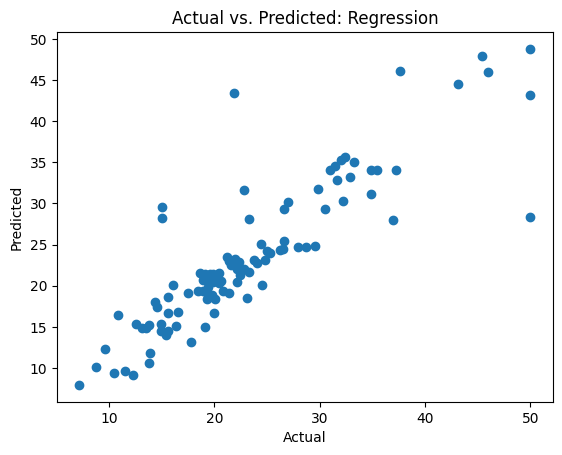

In [ ]:
# make a scatterplot
plt.scatter(x=y_test, y=y_pred_loaded)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted: Regression')
plt.show()

**Figure 5:** Actual vs. predicted on the test data (model from TPOT.)

HOW EASY WAS THAT?!

# Other Thoughts
Imagine if you use this in a loop... you could get MANY candidate models and see how the pipeline changes...

Try looking at [the arguments](http://epistasislab.github.io/tpot/api/) you can update.

Note that all of the pre-processing needs to happen BEFORE you fit your models.

# Resources
Here are some excellent resources to review.

**Examples**
* https://www.kdnuggets.com/2018/01/managing-machine-learning-workflows-scikit-learn-pipelines-part-4.html
* https://towardsdatascience.com/tpot-automated-machine-learning-in-python-4c063b3e5de9

**Documentation**
* https://epistasislab.github.io/tpot/using/
* https://epistasislab.github.io/tpot/examples/

**More on Pipelines**
(These are the three posts that lead up to the TPOT post above - Part 4.)
* https://www.kdnuggets.com/2017/12/managing-machine-learning-workflows-scikit-learn-pipelines-part-1.html
* https://www.kdnuggets.com/2018/01/managing-machine-learning-workflows-scikit-learn-pipelines-part-2.html
* https://www.kdnuggets.com/2018/01/managing-machine-learning-workflows-scikit-learn-pipelines-part-3.html